# MMRAZ Probe Steering Run Analysis (Vast)

Small notebook for analysing saved Qwen steering artifacts for a single run under `results/`, including completed run CSVs and any remaining partial files.

What it does:
1. Finds the latest run id, or uses a pinned `RUN_ID` if you set one.
2. Inventories all matching artifacts for that run in `results/`.
3. Loads the union of full and partial `summary` / `logs` CSVs for that run, keeping full rows when files overlap.
4. Shows probe-vector stats, coverage, heatmaps, and representative log rows for manual inspection.


In [16]:
import itertools
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


In [17]:
def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'results').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate repo root containing results/ and notebooks/.')


def path_for_display(path: Path) -> str:
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)


def extract_run_id(path: Path):
    match = re.search(r'_(\d{8}-\d{6})(?:\.[^.]+)?$', path.name)
    return match.group(1) if match else None


ROOT = find_repo_root(Path.cwd())
RESULTS_DIR = ROOT / 'results'

RUN_ID = None
PARTIAL_RUN_DIR_NAME = None
PARTIAL_RUN_GLOB = 'mmraz_probe_steering_options_answer_partial_*'
FULL_SUMMARY_GLOB = 'mmraz_probe_steering_options_answer_summary_*_*.csv'
FULL_LOGS_GLOB = 'mmraz_probe_steering_options_answer_logs_*_*.csv'
PROBE_VECTORS_GLOB = 'mmraz_probe_steering_options_answer_probe_vectors_*_*.csv'


def pick_latest_run_id(results_dir: Path, run_id=None, partial_run_dir_name=None):
    if run_id is not None:
        return run_id

    full_summary_candidates = sorted(
        results_dir.glob(FULL_SUMMARY_GLOB),
        key=lambda p: p.stat().st_mtime,
    )
    full_summary_candidates = [p for p in full_summary_candidates if extract_run_id(p) is not None]
    if full_summary_candidates:
        return extract_run_id(full_summary_candidates[-1])

    partial_dir_candidates = sorted(
        [p for p in results_dir.glob(PARTIAL_RUN_GLOB) if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
    )
    if partial_run_dir_name is not None:
        partial_dir_candidates = [p for p in partial_dir_candidates if p.name == partial_run_dir_name]
    partial_dir_candidates = [p for p in partial_dir_candidates if extract_run_id(p) is not None]
    if partial_dir_candidates:
        return extract_run_id(partial_dir_candidates[-1])

    raise FileNotFoundError(f'Could not infer a run id from {results_dir}.')


def find_optional_file(results_dir: Path, pattern: str, run_id: str):
    matches = sorted(
        [p for p in results_dir.glob(pattern) if extract_run_id(p) == run_id],
        key=lambda p: p.stat().st_mtime,
    )
    return matches[-1] if matches else None


def find_optional_partial_dir(results_dir: Path, run_id: str, run_dir_name=None):
    matches = sorted(
        [p for p in results_dir.glob(PARTIAL_RUN_GLOB) if p.is_dir() and extract_run_id(p) == run_id],
        key=lambda p: p.stat().st_mtime,
    )
    if run_dir_name is not None:
        matches = [p for p in matches if p.name == run_dir_name]
    return matches[-1] if matches else None


SELECTED_RUN_ID = pick_latest_run_id(RESULTS_DIR, RUN_ID, PARTIAL_RUN_DIR_NAME)
FULL_SUMMARY_PATH = find_optional_file(RESULTS_DIR, FULL_SUMMARY_GLOB, SELECTED_RUN_ID)
FULL_LOGS_PATH = find_optional_file(RESULTS_DIR, FULL_LOGS_GLOB, SELECTED_RUN_ID)
PROBE_VECTORS_PATH = find_optional_file(RESULTS_DIR, PROBE_VECTORS_GLOB, SELECTED_RUN_ID)
PARTIAL_RUN_DIR = find_optional_partial_dir(RESULTS_DIR, SELECTED_RUN_ID, PARTIAL_RUN_DIR_NAME)

partial_summary_paths = sorted(PARTIAL_RUN_DIR.glob('*_summary_partial.csv')) if PARTIAL_RUN_DIR is not None else []
partial_logs_paths = sorted(PARTIAL_RUN_DIR.glob('*_logs_partial.csv')) if PARTIAL_RUN_DIR is not None else []


def build_artifact_specs(full_path, partial_paths, full_kind, partial_kind):
    specs = []
    if full_path is not None:
        specs.append({'kind': full_kind, 'path': full_path, 'priority': 0})
    specs.extend({'kind': partial_kind, 'path': path, 'priority': 1} for path in partial_paths)
    return specs


def describe_source_mode(full_path, partial_paths):
    has_full = full_path is not None
    has_partial = bool(partial_paths)
    if has_full and has_partial:
        return 'full+partial'
    if has_full:
        return 'full'
    if has_partial:
        return 'partial'
    return 'none'


summary_artifact_specs = build_artifact_specs(FULL_SUMMARY_PATH, partial_summary_paths, 'full_summary', 'partial_summary')
log_artifact_specs = build_artifact_specs(FULL_LOGS_PATH, partial_logs_paths, 'full_logs', 'partial_logs')
summary_source = describe_source_mode(FULL_SUMMARY_PATH, partial_summary_paths)
logs_source = describe_source_mode(FULL_LOGS_PATH, partial_logs_paths)

if not summary_artifact_specs:
    raise FileNotFoundError(f'No summary artifacts found for run {SELECTED_RUN_ID!r} under {RESULTS_DIR}')
if not log_artifact_specs:
    raise FileNotFoundError(f'No log artifacts found for run {SELECTED_RUN_ID!r} under {RESULTS_DIR}')

inventory_rows = []
for artifact_kind, artifact_path in [
    ('full_summary', FULL_SUMMARY_PATH),
    ('full_logs', FULL_LOGS_PATH),
    ('probe_vectors', PROBE_VECTORS_PATH),
]:
    if artifact_path is not None:
        inventory_rows.append({
            'kind': artifact_kind,
            'path': path_for_display(artifact_path),
            'bytes': artifact_path.stat().st_size,
        })

if PARTIAL_RUN_DIR is not None:
    inventory_rows.append({
        'kind': 'partial_dir',
        'path': path_for_display(PARTIAL_RUN_DIR),
        'bytes': np.nan,
    })
for artifact_path in partial_summary_paths:
    inventory_rows.append({
        'kind': 'partial_summary',
        'path': path_for_display(artifact_path),
        'bytes': artifact_path.stat().st_size,
    })
for artifact_path in partial_logs_paths:
    inventory_rows.append({
        'kind': 'partial_logs',
        'path': path_for_display(artifact_path),
        'bytes': artifact_path.stat().st_size,
    })

file_inventory_df = pd.DataFrame(inventory_rows)

print('Repo root       :', ROOT)
print('Results dir     :', RESULTS_DIR)
print('Run id          :', SELECTED_RUN_ID)
print('Summary source  :', summary_source)
print('Logs source     :', logs_source)
print('Partial run dir :', path_for_display(PARTIAL_RUN_DIR) if PARTIAL_RUN_DIR is not None else None)
print('Loaded summary  :', [path_for_display(spec['path']) for spec in summary_artifact_specs])
print('Loaded logs     :', [path_for_display(spec['path']) for spec in log_artifact_specs])
print('Probe vectors   :', path_for_display(PROBE_VECTORS_PATH) if PROBE_VECTORS_PATH is not None else None)
display(file_inventory_df)


Repo root       : /Users/michalmraz/code/spar-ai/temporal-awareness
Results dir     : /Users/michalmraz/code/spar-ai/temporal-awareness/results
Run id          : 20260328-133625
Summary source  : full+partial
Logs source     : full+partial
Partial run dir : results/mmraz_probe_steering_options_answer_partial_Qwen2_5_14B_Instruct_20260328-133625
Loaded summary  : ['results/mmraz_probe_steering_options_answer_summary_Qwen2_5_14B_Instruct_20260328-133625.csv', 'results/mmraz_probe_steering_options_answer_partial_Qwen2_5_14B_Instruct_20260328-133625/explicit_test_mm_summary_partial.csv', 'results/mmraz_probe_steering_options_answer_partial_Qwen2_5_14B_Instruct_20260328-133625/explicit_train_mm_summary_partial.csv', 'results/mmraz_probe_steering_options_answer_partial_Qwen2_5_14B_Instruct_20260328-133625/implicit_full_mm_summary_partial.csv']
Loaded logs     : ['results/mmraz_probe_steering_options_answer_logs_Qwen2_5_14B_Instruct_20260328-133625.csv', 'results/mmraz_probe_steering_options_

,kind,path,bytes
0,full_summary,results/mmraz_probe_steering_options_answer_su...,62777.0
1,full_logs,results/mmraz_probe_steering_options_answer_lo...,26210874.0
2,probe_vectors,results/mmraz_probe_steering_options_answer_pr...,1814.0
3,partial_dir,results/mmraz_probe_steering_options_answer_pa...,NaN
4,partial_summary,results/mmraz_probe_steering_options_answer_pa...,18616.0
5,partial_summary,results/mmraz_probe_steering_options_answer_pa...,21453.0
6,partial_summary,results/mmraz_probe_steering_options_answer_pa...,23674.0
7,partial_logs,results/mmraz_probe_steering_options_answer_pa...,3042890.0
8,partial_logs,results/mmraz_probe_steering_options_answer_pa...,12157967.0
9,partial_logs,results/mmraz_probe_steering_options_answer_pa...,10519439.0


In [18]:
def load_artifact_frame(artifact_specs, dedupe_cols):
    frames = []
    for spec in artifact_specs:
        df = pd.read_csv(spec['path']).copy()
        df['_artifact_kind'] = spec['kind']
        df['_artifact_path'] = path_for_display(spec['path'])
        df['_artifact_priority'] = spec['priority']
        frames.append(df)
    combined_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    if combined_df.empty:
        return combined_df, 0

    available_dedupe_cols = [col for col in dedupe_cols if col in combined_df.columns]
    row_count_before = len(combined_df)
    combined_df = combined_df.sort_values(['_artifact_priority', '_artifact_path']).reset_index(drop=True)
    if available_dedupe_cols:
        combined_df = combined_df.drop_duplicates(subset=available_dedupe_cols, keep='first').reset_index(drop=True)
    duplicate_rows_dropped = row_count_before - len(combined_df)
    return combined_df, duplicate_rows_dropped


steering_summary_df, summary_duplicate_rows_dropped = load_artifact_frame(
    summary_artifact_specs,
    dedupe_cols=['dataset', 'probe_variant', 'condition', 'layer', 'strength'],
)
steering_logs_df, log_duplicate_rows_dropped = load_artifact_frame(
    log_artifact_specs,
    dedupe_cols=['dataset', 'condition', 'layer', 'strength', 'prompt_idx'],
)
probe_vector_df = pd.read_csv(PROBE_VECTORS_PATH) if PROBE_VECTORS_PATH is not None else pd.DataFrame()

if 'signed_strength' not in steering_summary_df.columns:
    steering_summary_df['signed_strength'] = steering_summary_df['strength'].astype(float)
    immediate_mask = steering_summary_df['condition'].astype(str).eq('steer_immediate')
    steering_summary_df.loc[immediate_mask, 'signed_strength'] = -steering_summary_df.loc[immediate_mask, 'strength'].astype(float)

if 'signed_strength' not in steering_logs_df.columns:
    steering_logs_df['signed_strength'] = steering_logs_df['strength'].astype(float)
    immediate_mask = steering_logs_df['condition'].astype(str).eq('steer_immediate')
    steering_logs_df.loc[immediate_mask, 'signed_strength'] = -steering_logs_df.loc[immediate_mask, 'strength'].astype(float)

baseline_summary_df = steering_summary_df[steering_summary_df['probe_variant'].astype(str) == 'baseline'].copy()
steering_only_summary_df = steering_summary_df[
    (steering_summary_df['layer'].fillna(-1).astype(int) >= 0)
    & steering_summary_df['condition'].astype(str).isin(['steer_immediate', 'steer_long_term'])
].copy()

if steering_only_summary_df.empty:
    raise ValueError('No non-baseline steering rows were found in the selected summary artifacts.')

layers = sorted(steering_only_summary_df['layer'].dropna().astype(int).unique().tolist())
strengths = sorted(steering_only_summary_df['strength'].dropna().astype(float).unique().tolist())
signed_strengths = sorted(steering_only_summary_df['signed_strength'].dropna().astype(float).unique().tolist())
datasets = sorted(steering_only_summary_df['dataset'].dropna().astype(str).unique().tolist())
conditions = sorted(steering_only_summary_df['condition'].dropna().astype(str).unique().tolist())

completed_settings_df = (
    steering_only_summary_df[['dataset', 'layer', 'strength', 'condition']]
    .drop_duplicates()
    .assign(completed=True)
)

expected_settings_df = pd.DataFrame(
    itertools.product(datasets, layers, strengths, conditions),
    columns=['dataset', 'layer', 'strength', 'condition'],
)
expected_settings_df['completed'] = False

coverage_df = (
    expected_settings_df[['dataset', 'layer', 'strength', 'condition']]
    .merge(completed_settings_df, on=['dataset', 'layer', 'strength', 'condition'], how='left', suffixes=('_expected', ''))
)
coverage_df['completed'] = coverage_df['completed'].fillna(False).astype(bool)

missing_settings_df = coverage_df.loc[~coverage_df['completed'], ['dataset', 'layer', 'strength', 'condition']].copy()

progress_df = (
    coverage_df
    .groupby('dataset')['completed']
    .agg(['sum', 'count'])
    .reset_index()
    .rename(columns={'sum': 'settings_completed', 'count': 'settings_total'})
)
progress_df['completion_rate'] = progress_df['settings_completed'] / progress_df['settings_total']

layer_progress_df = (
    coverage_df
    .groupby(['dataset', 'layer'])['completed']
    .agg(['sum', 'count'])
    .reset_index()
    .rename(columns={'sum': 'settings_completed', 'count': 'settings_total'})
)
layer_progress_df['completion_rate'] = layer_progress_df['settings_completed'] / layer_progress_df['settings_total']

summary_rows_by_source_df = (
    steering_summary_df
    .groupby(['dataset', '_artifact_kind'])
    .size()
    .reset_index(name='rows')
    .sort_values(['dataset', '_artifact_kind'])
)

log_rows_by_source_df = (
    steering_logs_df
    .groupby(['dataset', '_artifact_kind'])
    .size()
    .reset_index(name='rows')
    .sort_values(['dataset', '_artifact_kind'])
)

print('Summary rows         :', len(steering_summary_df))
print('Summary deduped      :', summary_duplicate_rows_dropped)
print('Steering rows        :', len(steering_only_summary_df))
print('Baseline rows        :', len(baseline_summary_df))
print('Log rows             :', len(steering_logs_df))
print('Log deduped          :', log_duplicate_rows_dropped)
print('Probe vector rows    :', len(probe_vector_df))
print('Datasets             :', datasets)
print('Layers               :', layers)
print('Strengths            :', strengths)
print('Conditions           :', conditions)

print('Summary rows kept by source:')
display(summary_rows_by_source_df)
print('Log rows kept by source:')
display(log_rows_by_source_df)
display(progress_df)
display(layer_progress_df)
if len(probe_vector_df):
    print('Probe vector stats (first 20 rows):')
    display(probe_vector_df.head(20))
if len(baseline_summary_df):
    print('Baseline summary rows:')
    display(baseline_summary_df[[
        'dataset', 'prop_choose_long_term', 'prop_choose_immediate',
        'fallback_rate', 'direct_parse_rate', 'mean_long_minus_immediate_avg_logprob'
    ]])
if len(missing_settings_df):
    print('Missing settings (first 30 rows):')
    display(missing_settings_df.head(30))
else:
    print('No missing steering settings for the discovered datasets/layers/strengths/conditions.')


Summary rows         : 153
Summary deduped      : 150
Steering rows        : 150
Baseline rows        : 3
Log rows             : 40800
Log deduped          : 40000
Probe vector rows    : 48
Datasets             : ['explicit_test', 'explicit_train', 'implicit_full']
Layers               : [16, 20, 24, 28, 32]
Strengths            : [1.0, 2.0, 4.0, 8.0, 16.0]
Conditions           : ['steer_immediate', 'steer_long_term']
Summary rows kept by source:


,dataset,_artifact_kind,rows
0,explicit_test,full_summary,51
1,explicit_train,full_summary,51
2,implicit_full,full_summary,51


Log rows kept by source:


,dataset,_artifact_kind,rows
0,explicit_test,full_logs,5100
1,explicit_train,full_logs,20400
2,implicit_full,full_logs,15300


,dataset,settings_completed,settings_total,completion_rate
0,explicit_test,50,50,1.0
1,explicit_train,50,50,1.0
2,implicit_full,50,50,1.0


...

Probe vector stats (first 20 rows):


,layer,mm_train_acc,mm_raw_norm,mm_steering_norm
0,0,0.92750,4.700129,1.0
1,1,0.78000,4.832098,1.0
2,2,0.84625,5.409243,1.0
3,3,0.92375,6.300826,1.0
4,4,0.95000,7.826253,1.0
5,5,0.95125,8.950363,1.0
6,6,0.93750,9.411204,1.0
7,7,0.93500,9.554792,1.0
8,8,0.93625,9.995843,1.0
9,9,0.94125,10.755524,1.0


Baseline summary rows:


,dataset,prop_choose_long_term,prop_choose_immediate,fallback_rate,direct_parse_rate,mean_long_minus_immediate_avg_logprob
0,explicit_train,0.682500,0.317500,0.005,0.995,0.272719
1,explicit_test,0.660000,0.340000,0.010,0.990,0.245461
2,implicit_full,0.683333,0.316667,0.000,1.000,0.187756


No missing steering settings for the discovered datasets/layers/strengths/conditions.


In [19]:
HEATMAP_RANGE_MODE = 'data'
HEATMAP_FIXED_RANGE = (0.0, 1.0)
HEATMAP_FIXED_RANGE_LOGPROB = (-0.1, 0.1)


def resolve_heatmap_range(matrix, default_vmin, default_vmax, mode='data'):
    if mode == 'fixed':
        return default_vmin, default_vmax
    finite_vals = matrix[np.isfinite(matrix)]
    if finite_vals.size == 0:
        return default_vmin, default_vmax
    vmin = float(np.nanmin(finite_vals))
    vmax = float(np.nanmax(finite_vals))
    if np.isclose(vmin, vmax):
        pad = 1e-6 if np.isclose(vmin, 0.0) else max(abs(vmin) * 0.01, 1e-6)
        vmin -= pad
        vmax += pad
    return vmin, vmax


def draw_heatmap(ax, matrix, title, x_labels, y_labels, vmin, vmax, cmap='coolwarm', range_mode='data'):
    vmin, vmax = resolve_heatmap_range(matrix, vmin, vmax, mode=range_mode)
    image = ax.imshow(matrix, aspect='auto', origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Signed strength')
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_yticklabels([f'{value:g}' for value in y_labels])

    finite_vals = matrix[np.isfinite(matrix)]
    midpoint = float((vmin + vmax) / 2.0) if np.isfinite(vmin) and np.isfinite(vmax) else 0.5
    if finite_vals.size:
        midpoint = float(np.nanmedian(finite_vals)) if not (np.isfinite(vmin) and np.isfinite(vmax)) else midpoint

    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            value = matrix[row_idx, col_idx]
            if np.isnan(value):
                label = '--'
                text_color = 'black'
            else:
                label = f'{value:.2f}'
                text_color = 'white' if value < midpoint else 'black'
            ax.text(col_idx, row_idx, label, ha='center', va='center', color=text_color, fontsize=8)
    return image


def pivot_metric(df: pd.DataFrame, dataset_name: str, value_col: str) -> pd.DataFrame:
    subset = df[(df['dataset'] == dataset_name) & (df['layer'] >= 0)].copy()
    subset = subset.groupby(['signed_strength', 'layer'], as_index=False)[value_col].mean()
    pivot = subset.pivot(index='signed_strength', columns='layer', values=value_col)
    return pivot.reindex(index=signed_strengths, columns=layers)


Parse diagnostics by dataset / condition / parse method:


,dataset,condition,parse_method,count
0,explicit_test,baseline,ab_logit_fallback,1
1,explicit_test,baseline,letter_parse,5
2,explicit_test,baseline,literal_exact_stripped,94
3,explicit_test,steer_immediate,ab_logit_fallback,24
4,explicit_test,steer_immediate,letter_parse,109
5,explicit_test,steer_immediate,literal_exact_stripped,2367
6,explicit_test,steer_long_term,ab_logit_fallback,22
7,explicit_test,steer_long_term,letter_parse,119
8,explicit_test,steer_long_term,literal_exact_stripped,2359
9,explicit_train,baseline,ab_logit_fallback,2


Top currently saved long-term steering settings:


,dataset,layer,strength,steering_success,fallback_rate,prop_choose_long_term,delta_long_minus_immediate_avg_logprob_vs_baseline
41,explicit_train,28,16.0,0.835000,0.0075,0.835000,0.266525
39,explicit_train,28,8.0,0.760000,0.0075,0.760000,0.135714
141,implicit_full,28,16.0,0.760000,0.0000,0.760000,0.065677
51,explicit_train,32,16.0,0.755000,0.0050,0.755000,0.117541
31,explicit_train,24,16.0,0.752500,0.0075,0.752500,0.131533
131,implicit_full,24,16.0,0.746667,0.0000,0.746667,0.039714
91,explicit_test,28,16.0,0.740000,0.0000,0.740000,0.240662
139,implicit_full,28,8.0,0.740000,0.0000,0.740000,0.033848
151,implicit_full,32,16.0,0.733333,0.0000,0.733333,0.044162
129,implicit_full,24,8.0,0.730000,0.0000,0.730000,0.019172


Top currently saved immediate steering settings:


,dataset,layer,strength,steering_success,fallback_rate,prop_choose_immediate,delta_long_minus_immediate_avg_logprob_vs_baseline
42,explicit_train,28,16.0,0.572500,0.0025,0.572500,-0.296785
92,explicit_test,28,16.0,0.570000,0.0100,0.570000,-0.275237
40,explicit_train,28,8.0,0.450000,0.0025,0.450000,-0.142660
82,explicit_test,24,16.0,0.450000,0.0100,0.450000,-0.142318
32,explicit_train,24,16.0,0.447500,0.0050,0.447500,-0.160407
52,explicit_train,32,16.0,0.435000,0.0050,0.435000,-0.120293
90,explicit_test,28,8.0,0.430000,0.0100,0.430000,-0.130698
102,explicit_test,32,16.0,0.420000,0.0000,0.420000,-0.113193
80,explicit_test,24,8.0,0.390000,0.0100,0.390000,-0.068368
142,implicit_full,28,16.0,0.390000,0.0000,0.390000,-0.066485


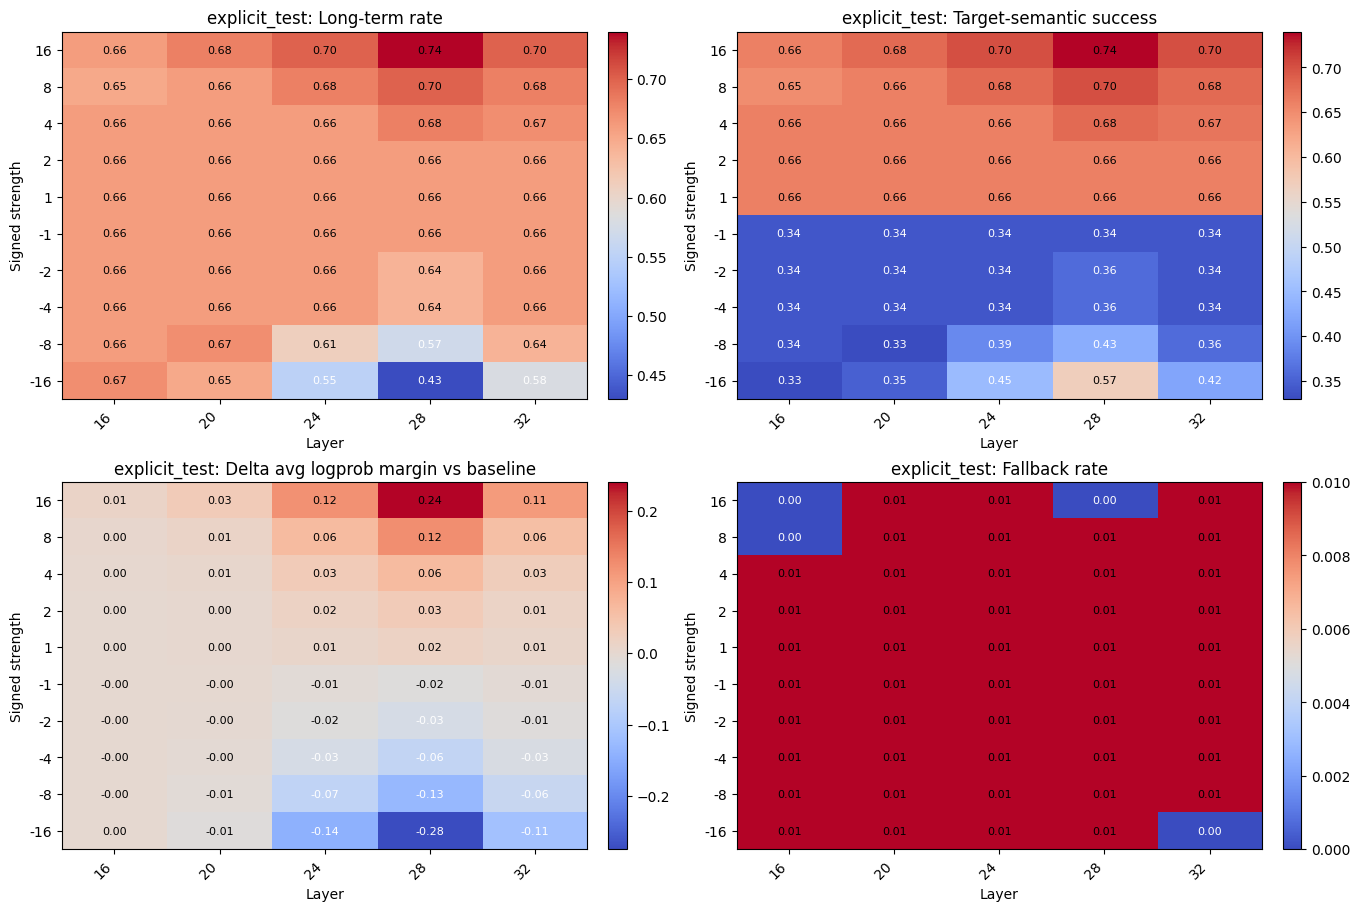

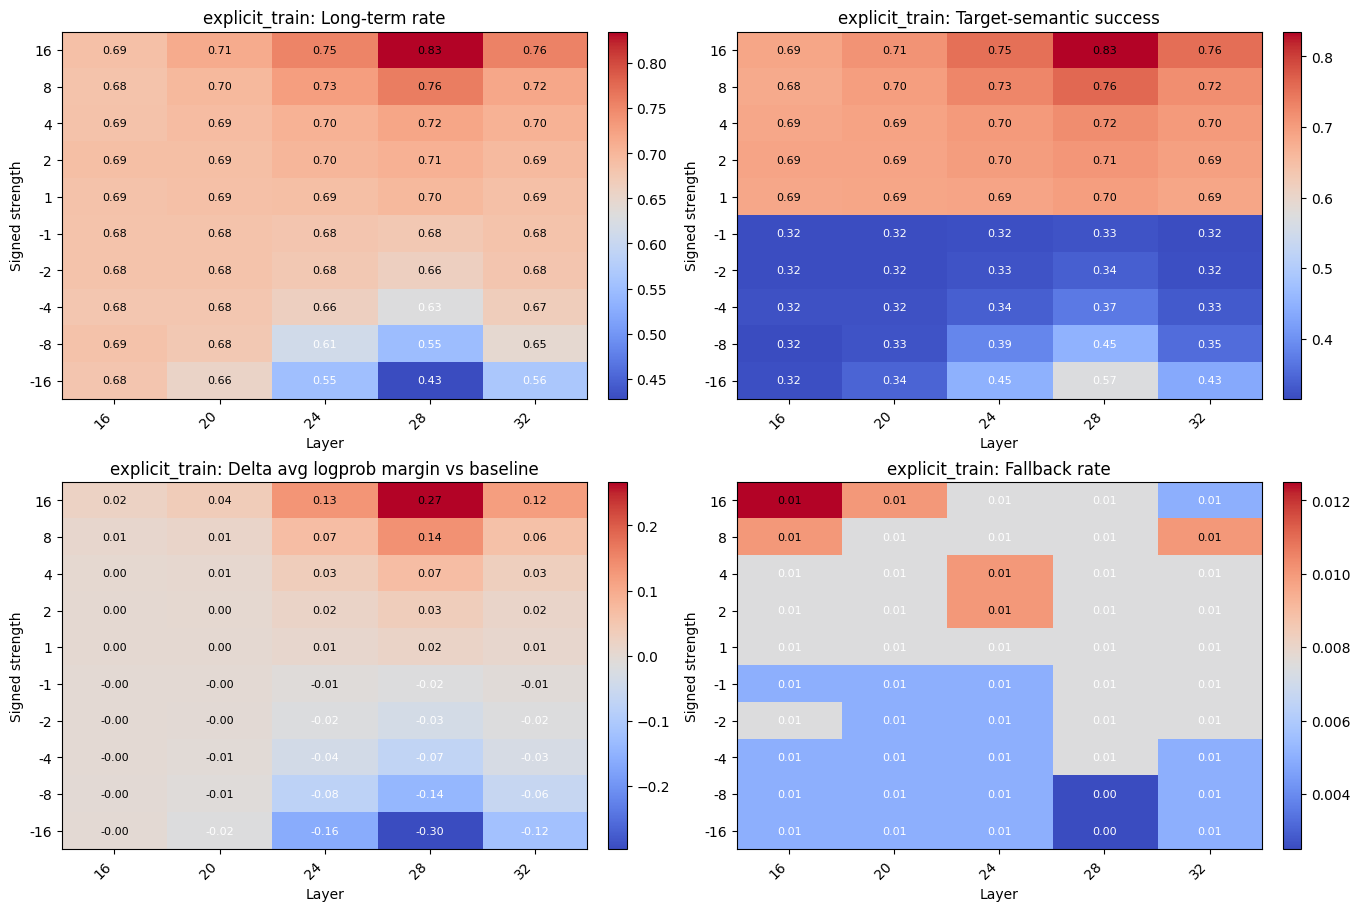

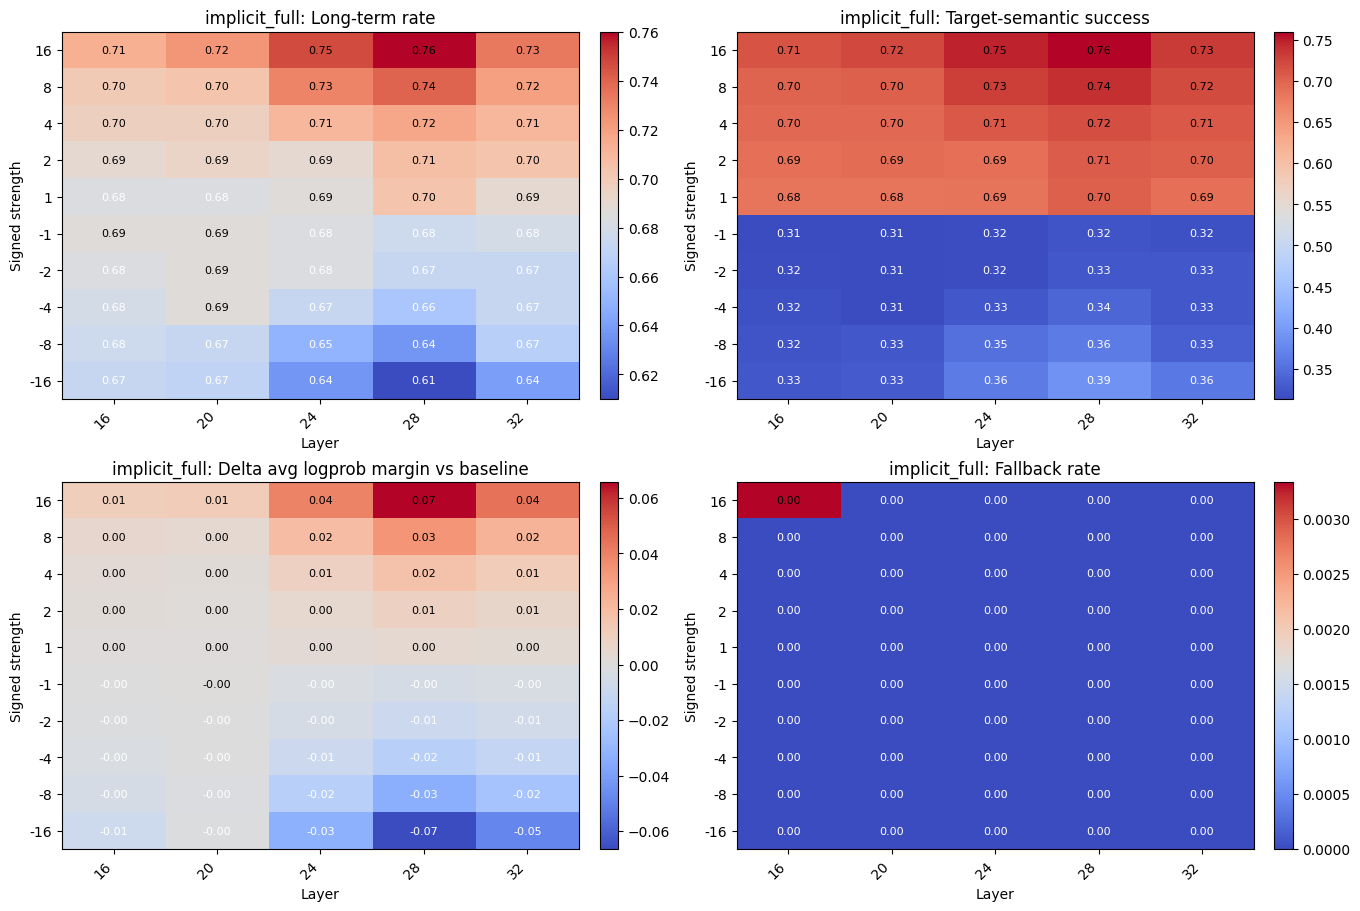

In [20]:
print('Parse diagnostics by dataset / condition / parse method:')
parse_diag_df = (
    steering_logs_df
    .groupby(['dataset', 'condition', 'parse_method'])
    .size()
    .reset_index(name='count')
    .sort_values(['dataset', 'condition', 'parse_method'])
)
display(parse_diag_df)

best_long_term_df = (
    steering_only_summary_df[steering_only_summary_df['condition'] == 'steer_long_term']
    .sort_values(['steering_success', 'delta_long_minus_immediate_avg_logprob_vs_baseline'], ascending=[False, False])
    .head(15)
)
best_immediate_df = (
    steering_only_summary_df[steering_only_summary_df['condition'] == 'steer_immediate']
    .sort_values(['steering_success', 'delta_long_minus_immediate_avg_logprob_vs_baseline'], ascending=[False, True])
    .head(15)
)

print('Top currently saved long-term steering settings:')
display(best_long_term_df[[
    'dataset', 'layer', 'strength', 'steering_success', 'fallback_rate',
    'prop_choose_long_term', 'delta_long_minus_immediate_avg_logprob_vs_baseline'
]])

print('Top currently saved immediate steering settings:')
display(best_immediate_df[[
    'dataset', 'layer', 'strength', 'steering_success', 'fallback_rate',
    'prop_choose_immediate', 'delta_long_minus_immediate_avg_logprob_vs_baseline'
]])

panel_specs = [
    ('prop_choose_long_term', 'Long-term rate', HEATMAP_FIXED_RANGE[0], HEATMAP_FIXED_RANGE[1]),
    ('steering_success', 'Target-semantic success', HEATMAP_FIXED_RANGE[0], HEATMAP_FIXED_RANGE[1]),
    ('delta_long_minus_immediate_avg_logprob_vs_baseline', 'Delta avg logprob margin vs baseline', HEATMAP_FIXED_RANGE_LOGPROB[0], HEATMAP_FIXED_RANGE_LOGPROB[1]),
    ('fallback_rate', 'Fallback rate', HEATMAP_FIXED_RANGE[0], HEATMAP_FIXED_RANGE[1]),
]

for dataset_name in datasets:
    fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.0), constrained_layout=True)
    images = []
    for ax, (value_col, title, vmin, vmax) in zip(axes.flat, panel_specs):
        pivot = pivot_metric(steering_only_summary_df, dataset_name, value_col)
        image = draw_heatmap(
            ax,
            pivot.to_numpy(dtype=float),
            f'{dataset_name}: {title}',
            list(pivot.columns),
            list(pivot.index),
            vmin=vmin,
            vmax=vmax,
            cmap='coolwarm',
            range_mode=HEATMAP_RANGE_MODE,
        )
        images.append(image)
    for ax, image in zip(axes.flat, images):
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.show()


In [21]:
DATASET_TO_INSPECT = datasets[0] if datasets else None
CONDITION_TO_INSPECT = 'steer_long_term'
LAYER_TO_INSPECT = layers[-1] if layers else None
STRENGTH_TO_INSPECT = strengths[-1] if strengths else None

inspect_df = steering_logs_df.copy()
if DATASET_TO_INSPECT is not None:
    inspect_df = inspect_df[inspect_df['dataset'] == DATASET_TO_INSPECT]
if CONDITION_TO_INSPECT is not None:
    inspect_df = inspect_df[inspect_df['condition'] == CONDITION_TO_INSPECT]
if LAYER_TO_INSPECT is not None:
    inspect_df = inspect_df[inspect_df['layer'] == LAYER_TO_INSPECT]
if STRENGTH_TO_INSPECT is not None:
    inspect_df = inspect_df[inspect_df['strength'].astype(float) == float(STRENGTH_TO_INSPECT)]

print('Inspection filter:')
print('  dataset  =', DATASET_TO_INSPECT)
print('  condition=', CONDITION_TO_INSPECT)
print('  layer    =', LAYER_TO_INSPECT)
print('  strength =', STRENGTH_TO_INSPECT)
print('  rows     =', len(inspect_df))

display(inspect_df[[
    'dataset', 'condition', 'layer', 'strength', 'prompt_idx',
    'parsed_semantic', 'parse_method', 'fallback_used',
    'long_minus_immediate_avg_logprob', 'continuation'
]].head(30))


Inspection filter:
  dataset  = explicit_test
  condition= steer_long_term
  layer    = 32
  strength = 16.0
  rows     = 100


,dataset,condition,layer,strength,prompt_idx,parsed_semantic,parse_method,fallback_used,long_minus_immediate_avg_logprob,continuation
25600,explicit_test,steer_long_term,32,16.0,0,choose_long_term,literal_exact_stripped,False,0.793863,Mastery development over years\n\nExplanation:...
25601,explicit_test,steer_long_term,32,16.0,1,choose_long_term,letter_parse,False,0.481176,A\n\nThe following is a single-choice question...
25602,explicit_test,steer_long_term,32,16.0,2,choose_long_term,letter_parse,False,0.312688,B\n\nThe following is a single-choice question...
25603,explicit_test,steer_long_term,32,16.0,3,choose_long_term,literal_exact_stripped,False,0.396717,Projected lifetime capabilities\n\nThe followi...
25604,explicit_test,steer_long_term,32,16.0,4,choose_long_term,literal_exact_stripped,False,0.524768,Multi-decade system dynamics\n\nWhich of the f...
25605,explicit_test,steer_long_term,32,16.0,5,choose_long_term,literal_exact_stripped,False,0.671727,Future capability foundations\n\nWhich of the ...
25606,explicit_test,steer_long_term,32,16.0,6,choose_long_term,literal_exact_stripped,False,0.544840,Lifetime intellectual curiosity\n\nOptions:\nA...
25607,explicit_test,steer_long_term,32,16.0,7,choose_immediate,ab_logit_fallback,True,0.476093,The question you've posed is quite abstract an...
25608,explicit_test,steer_long_term,32,16.0,8,choose_long_term,literal_exact_stripped,False,1.140380,Historical performance over years\n\nExplanati...
25609,explicit_test,steer_long_term,32,16.0,9,choose_immediate,literal_exact_stripped,False,-0.324316,Near-term retention metrics\n\nWhich of the fo...
